In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
################################################################################

In [4]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [20]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 1152 CL parcels and 1048 nonCL parcels


In [21]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 374 CL parcels and 314 nonCL parcels


In [5]:
#ALL/DEEP/SHALLOW CL vs non-CL Tracked Parcel Plots
################################################################################

In [6]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)


In [7]:
# Loading Important Variables
##############
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # th_data=data['th'].data
    # buoyancy_data=data['buoyancy'].data

    # import h5py
    # with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
    #     theta_e_data = f['theta_e'][:]
    
    print('done')
    empty_like=True

loading neccessary variables
done


In [8]:
#FINDING MEAN CLOUD BASE
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'


if type=='all':
    out_nz=ALL_out_nz.copy()
if type=='deep':
    out_nz=DEEP_out_nz.copy()
if type=='shallow':
    out_nz=SHALLOW_out_nz.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_nz.shape[0]):
    p=out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        var1=w_data[t,z,y,x]
        var2=qc_plus_qi[t,z,y,x]

        if (var2>=qcqi_thresh):
        # if (var1>=w_thresh2) & (var2>=qcqi_thresh):
            profile_array[z,0]+=1
            # cloudbase_lst.append(zh[z])
            break

# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

1.5475868


In [9]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [58]:
#MAKING PROFILE ARRAY

#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

dx=(data['xf'][1].item()-data['xf'][0].item())# km *1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())# km *1e3 #meters

def tracked_AREA(type,type2,updraft_type):
    after=4 #20 minutes

    if type=='all':
        if type2=='CL':
            out_nz=ALL_out_nz.copy()
        if type2=='nonCL':
            out_nz=ALL_save_nz.copy() 
        if type2=='SBZ':
            out_nz=ALL_SBZ_out_nz.copy()
        if type2=='nonSBZ':
            out_nz=ALL_nonSBZ_out_nz.copy() 
    if type=='shallow':
        if type2=='CL':
            out_nz=SHALLOW_out_nz.copy() 
        if type2=='nonCL':
            out_nz=SHALLOW_save_nz.copy()
        if type2=='SBZ':
            out_nz=SHALLOW_SBZ_out_nz.copy() 
        if type2=='nonSBZ':
            out_nz=SHALLOW_nonSBZ_out_nz.copy()
    if type=='deep':
        if type2=='CL':
            out_nz=DEEP_out_nz.copy()
        if type2=='nonCL':
            out_nz=DEEP_save_nz.copy()
        if type2=='SBZ':
            out_nz=DEEP_SBZ_out_nz.copy()
        if type2=='nonSBZ':
            out_nz=DEEP_nonSBZ_out_nz.copy()
   
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):

            if True==True: #x in np.arange(15,500) and y in np.arange(15,85): (OLD) USED TO AVOID BOUNDARIES
    
                #CALCULATING AREA (CURRENTLY IGNORES CASES WHERE UPDRAFT CROSSES THE BOUNDARY)
                ########################################################
                #FINDING XLENGTH
                x_slice=w_data[t,z,y,:]
                x_slice2=qc_plus_qi[t,z,y,:]
                
                if updraft_type=='general':
                    # x_slice[(x_slice >= w_thresh1)] = 1; x_slice[x_slice < w_thresh1] = 0
                    x_slice = np.where(x_slice >= w_thresh1, 1, 0)
                elif updraft_type=='cloudy':
                    # x_slice[(x_slice>=w_thresh2)&(x_slice2>=qcqi_thresh)]=1; x_slice[(x_slice<w_thresh2)|(x_slice2<qcqi_thresh)]=0
                    x_slice = np.where((x_slice >= w_thresh2) & (x_slice2 >= qcqi_thresh), 1, 0)

                if np.all(x_slice[x+1:]==1) or np.all(x_slice[:(x-1)+1]==1): #*TOO AVOID BOUNDARY CASES*
                    continue #*TOO AVOID BOUNDARY CASES*
                # x_right=np.where(x_slice[x+1:]==0)[0][0]+(x+1)
                # x_left=np.where(x_slice[:(x-1)+1]==0)[0][-1]
                x_right=np.where(x_slice[x:]==0)[0][0]+(x)
                x_left=np.where(x_slice[:(x)+1]==0)[0][-1]
                x_length=(x_right-x_left)*dx
                
                #FINDING YLENGTH
                y_slice=w_data[t,z,:,x]
                y_slice2=qc_plus_qi[t,z,:,x]
                
                if updraft_type=='general':
                    # y_slice[(y_slice>=w_thresh1)]=1; y_slice[y_slice<w_thresh1]=0
                    y_slice = np.where(y_slice >= w_thresh1, 1, 0)
                elif updraft_type=='cloudy':
                    y_slice = np.where((y_slice >= w_thresh2) & (y_slice2 >= qcqi_thresh), 1, 0)

                if np.all(y_slice[y+1:]==1) or np.all(y_slice[:(y-1)+1]==1): #*TOO AVOID BOUNDARY CASES*
                    continue #*TOO AVOID BOUNDARY CASES*
                # y_right=np.where(y_slice[y+1:]==0)[0][0]+(y+1)
                # y_left=np.where(y_slice[:(y-1)+1]==0)[0][-1]
                y_right=np.where(y_slice[y:]==0)[0][0]+(y)
                y_left=np.where(y_slice[:(y)+1]==0)[0][-1]
                y_length=(y_right-y_left)*dy
                
                AREA=x_length*y_length*np.pi/4
                ########################################################
            else:
                continue

            #ADDING TO PROFILE
            var=AREA
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

In [30]:
print('ALL')
CL_ALL_profile_array_AREA_general=tracked_AREA(type='all',type2='CL',updraft_type='general')
CL_ALL_profile_array_AREA_cloudy=tracked_AREA(type='all',type2='CL',updraft_type='cloudy')
nonCL_ALL_profile_array_AREA_general=tracked_AREA(type='all',type2='nonCL',updraft_type='general')
nonCL_ALL_profile_array_AREA_cloudy=tracked_AREA(type='all',type2='nonCL',updraft_type='cloudy')

print('SHALLOW')
CL_SHALLOW_profile_array_AREA_general=tracked_AREA(type='shallow',type2='CL',updraft_type='general')
CL_SHALLOW_profile_array_AREA_cloudy=tracked_AREA(type='shallow',type2='CL',updraft_type='cloudy')

nonCL_SHALLOW_profile_array_AREA_general=tracked_AREA(type='shallow',type2='nonCL',updraft_type='general')
nonCL_SHALLOW_profile_array_AREA_cloudy=tracked_AREA(type='shallow',type2='nonCL',updraft_type='cloudy')

print('DEEP')
CL_DEEP_profile_array_AREA_general=tracked_AREA(type='deep',type2='CL',updraft_type='general')
CL_DEEP_profile_array_AREA_cloudy=tracked_AREA(type='deep',type2='CL',updraft_type='cloudy')

nonCL_DEEP_profile_array_AREA_general=tracked_AREA(type='deep',type2='nonCL',updraft_type='general')
nonCL_DEEP_profile_array_AREA_cloudy=tracked_AREA(type='deep',type2='nonCL',updraft_type='cloudy')



ALL
SHALLOW
DEEP


(-1.8549581468614662, 54.345396041507165)
(-0.7294574257917703, 16.0006059714593)


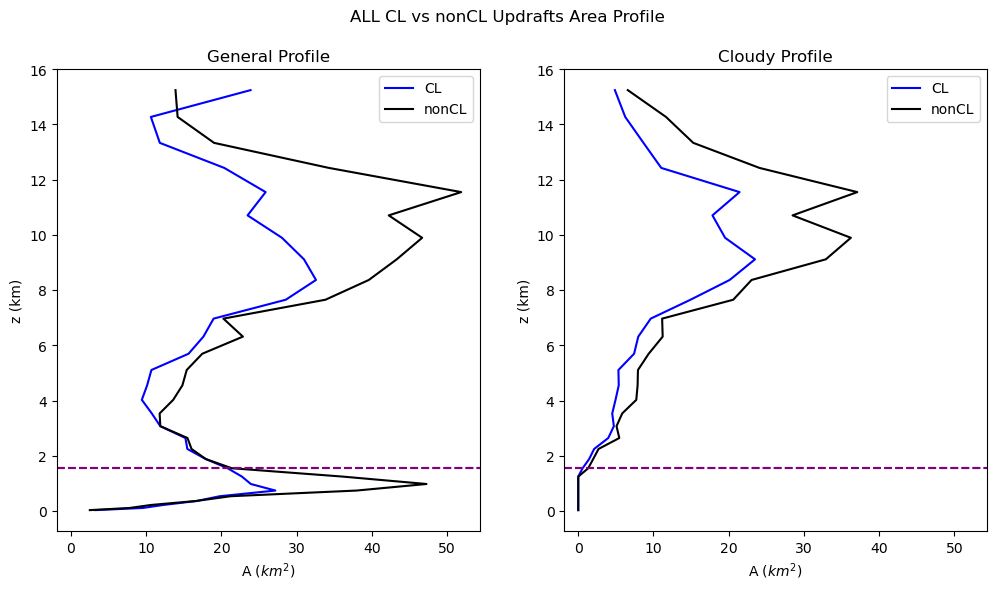

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_ALL_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_ALL_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_ALL_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonCL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_ALL_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonCL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('ALL CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-0.9424634150070516, 37.568706668747105)
(-0.19490003557875754, 4.7749007769860325)


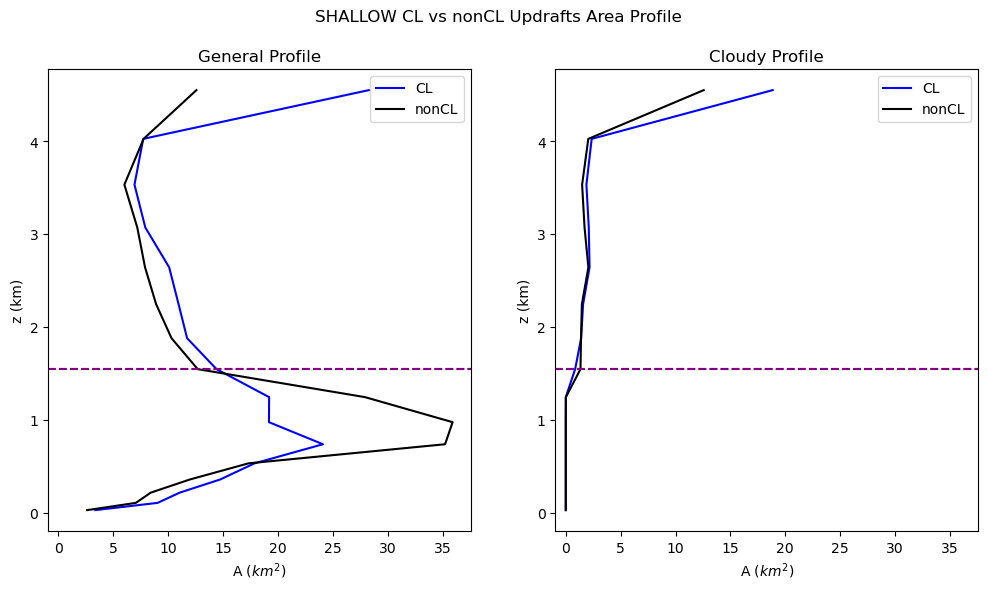

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_SHALLOW_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_SHALLOW_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_SHALLOW_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonCL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_SHALLOW_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonCL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('SHALLOW CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-3.0821281203337905, 112.01320573613533)
(-0.7294574257917703, 16.0006059714593)


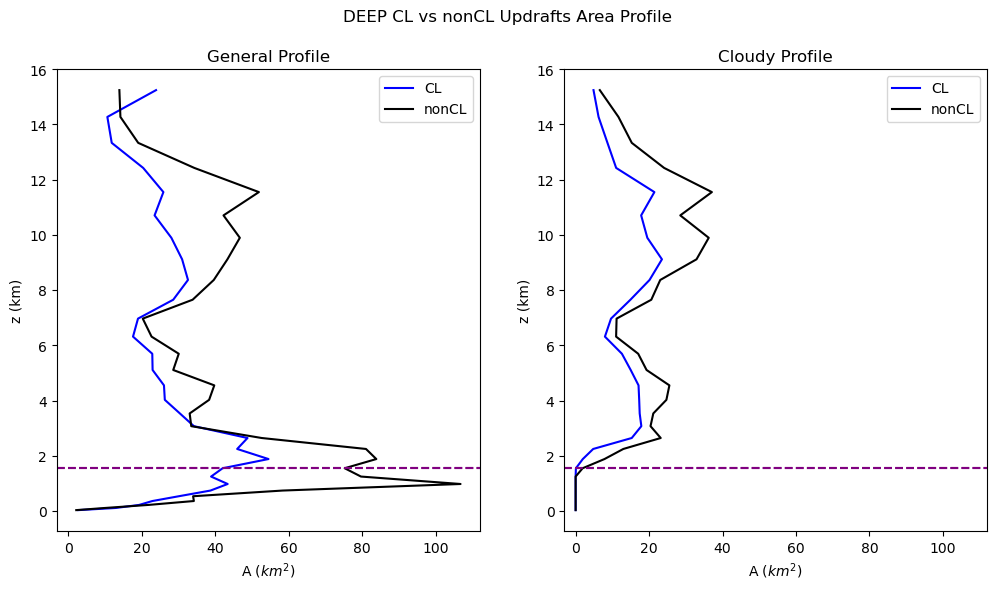

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_DEEP_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_DEEP_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_DEEP_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonCL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_DEEP_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonCL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('DEEP CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

In [ ]:
#SBZ

In [54]:
#FINDING SBZ CONVERGENCE

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

TF=False
if TF==False:
    print('Loading In Data')
    u_data=data['u'].interp(xf=data['xh']).data
    v_data=data['v'].interp(yf=data['yh']).data
    TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    print('calculating convergence and taking mean')
    Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs


# SUBSETTING OUT SBZS

def subset_SBZ(out_nz):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_nz.shape[0]):
        
        row=out_nz[ind]
        p=row[0]
        t=row[4]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_nz=out_nz[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

    valid_range=np.arange(out_nz.shape[0])
    nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
    return SBZ_out_nz,nonSBZ_out_nz

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################
[ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)
SHALLOW_SBZ_out_nz=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_nz)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_nz=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_nz)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_nz=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_nz)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_nz=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_nz)} DEEP nonSBZ CL parcels')

Loading In Data
calculating convergence and taking mean
there are a total of 117 ALL SBZ CL parcels
there are a total of 1971 ALL nonSBZ CL parcels
there are a total of 60 SHALLOW SBZ CL parcels
there are a total of 1092 SHALLOW nonSBZ CL parcels
there are a total of 37 DEEP SBZ CL parcels
there are a total of 337 DEEP nonSBZ CL parcels


In [59]:
print('ALL')
SBZ_ALL_profile_array_AREA_general=tracked_AREA(type='all',type2='SBZ',updraft_type='general')
SBZ_ALL_profile_array_AREA_cloudy=tracked_AREA(type='all',type2='SBZ',updraft_type='cloudy')
nonSBZ_ALL_profile_array_AREA_general=tracked_AREA(type='all',type2='nonSBZ',updraft_type='general')
nonSBZ_ALL_profile_array_AREA_cloudy=tracked_AREA(type='all',type2='nonSBZ',updraft_type='cloudy')

print('SHALLOW')
SBZ_SHALLOW_profile_array_AREA_general=tracked_AREA(type='shallow',type2='SBZ',updraft_type='general')
SBZ_SHALLOW_profile_array_AREA_cloudy=tracked_AREA(type='shallow',type2='SBZ',updraft_type='cloudy')

nonSBZ_SHALLOW_profile_array_AREA_general=tracked_AREA(type='shallow',type2='nonSBZ',updraft_type='general')
nonSBZ_SHALLOW_profile_array_AREA_cloudy=tracked_AREA(type='shallow',type2='nonSBZ',updraft_type='cloudy')

print('DEEP')
SBZ_DEEP_profile_array_AREA_general=tracked_AREA(type='deep',type2='SBZ',updraft_type='general')
SBZ_DEEP_profile_array_AREA_cloudy=tracked_AREA(type='deep',type2='SBZ',updraft_type='cloudy')

nonSBZ_DEEP_profile_array_AREA_general=tracked_AREA(type='deep',type2='nonSBZ',updraft_type='general')
nonSBZ_DEEP_profile_array_AREA_cloudy=tracked_AREA(type='deep',type2='nonSBZ',updraft_type='cloudy')



ALL
SHALLOW
DEEP


(-5.0868121921772875, 106.82305603572304)
(-0.7294574257917703, 16.0006059714593)


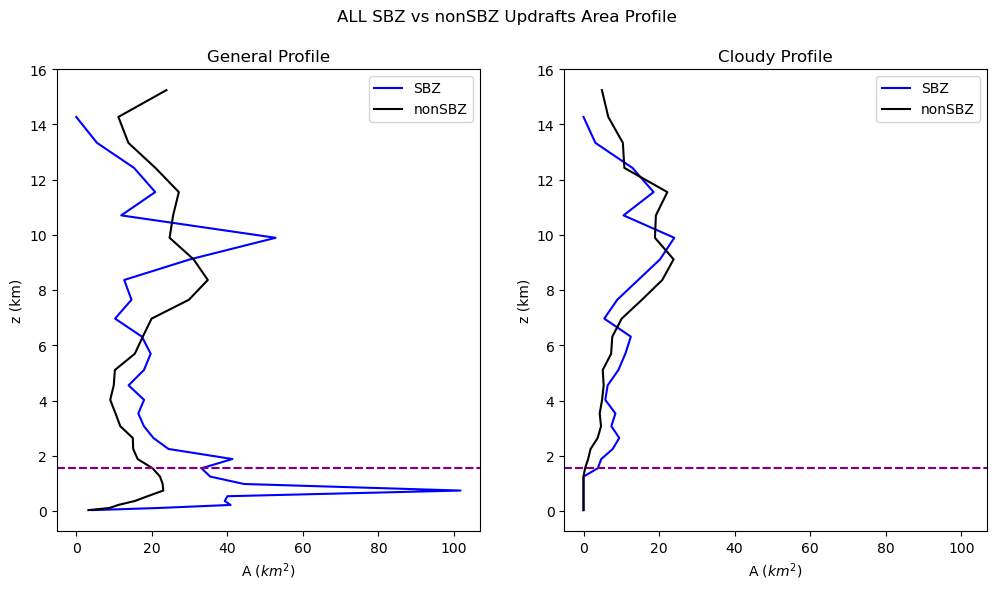

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_ALL_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_ALL_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_ALL_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_ALL_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('ALL SBZ vs nonSBZ Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-2.0164512926772518, 115.46883566233109)
(-0.19490003557875754, 4.7749007769860325)


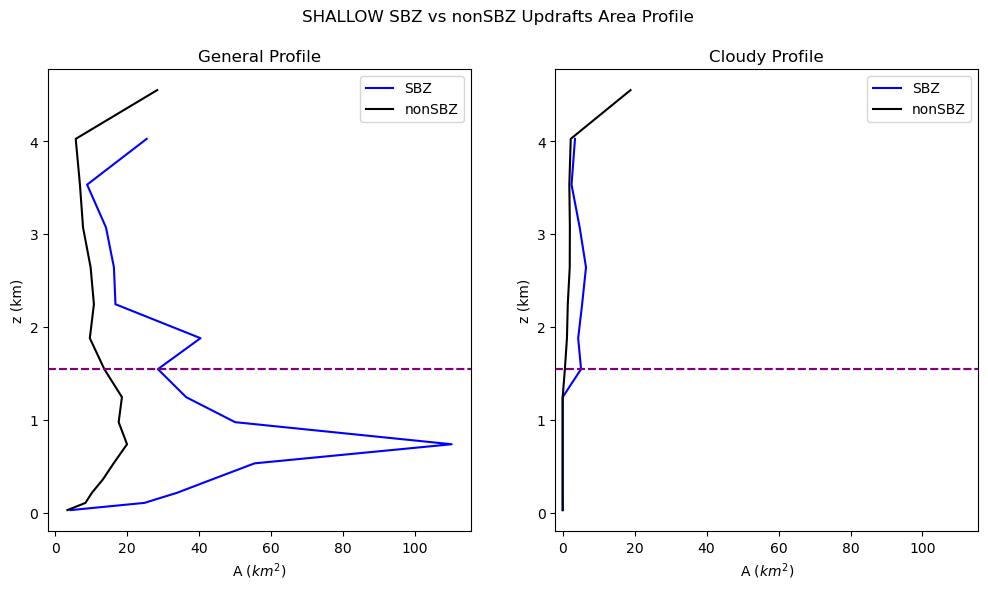

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_SHALLOW_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_SHALLOW_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_SHALLOW_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_SHALLOW_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('SHALLOW SBZ vs nonSBZ Updrafts Area Profile')
ax[0].legend();ax[1].legend()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_DEEP_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='blue',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_DEEP_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='blue',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_DEEP_profile_array_AREA_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_DEEP_profile_array_AREA_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('DEEP CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-4.928298274307707, 103.49426376046183)
(-0.7294574257917703, 16.0006059714593)
